# Inspect evedataset integration

Fast visual sanity check of `EveBundle` against the sample bundle: stimulus, face crop, eye-corner coordinates, and normalized gaze validity. Mirrors `tests/test_evedataset_integration.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from evedataset import EveBundle

EVEDATASET_REPO = Path.cwd().resolve().parents[1] / "eve_shared" / "EveDataset"
BUNDLE_DIR = EVEDATASET_REPO / "bundle"
FACE_CROPS_ROOT = EVEDATASET_REPO / "eve_out"

bundle = EveBundle.load(BUNDLE_DIR)
bundle

EveBundle(C:\Users\ulloa\Miooooo\Master\thesis\Projects\eve_shared\EveDataset\bundle, 3096 samples, 29844 webgazer runs)

In [2]:
# Pick the first exp_key with both face-crop (F6) and gaze-norm (F7) coverage.
exp_key = next(
    ek for ek in bundle.samples_df["exp_key"]
    if bundle.has_gaze_norm(ek) and bundle.has_face_crops(ek)
)
print("exp_key:", exp_key)
bundle.samples_df[bundle.samples_df["exp_key"] == exp_key]

exp_key: train13_step027


,exp_key,subject,stimulus_name,split,valid,stimulus_path
0,train13_step027,train13,MIT-i2130236527,train,True,stimuli/train13_step027.png


In [3]:
frame_validity = bundle.get_frame_validity(exp_key)
gaze_left = bundle.get_normalized_gaze(exp_key, "left")
gaze_right = bundle.get_normalized_gaze(exp_key, "right")

valid_frames = [
    f for f in range(90)
    if frame_validity[f] and gaze_left["validity"][f] and gaze_right["validity"][f]
]
print(f"frame_validity: {frame_validity.sum()}/90")
print(f"left gaze validity: {gaze_left['validity'].sum()}/90")
print(f"right gaze validity: {gaze_right['validity'].sum()}/90")
print(f"fully valid frames (both gates): {len(valid_frames)}")

frame = valid_frames[0]
print("inspecting frame:", frame)

frame_validity: 59/90
left gaze validity: 59/90
right gaze validity: 60/90
fully valid frames (both gates): 59
inspecting frame: 15


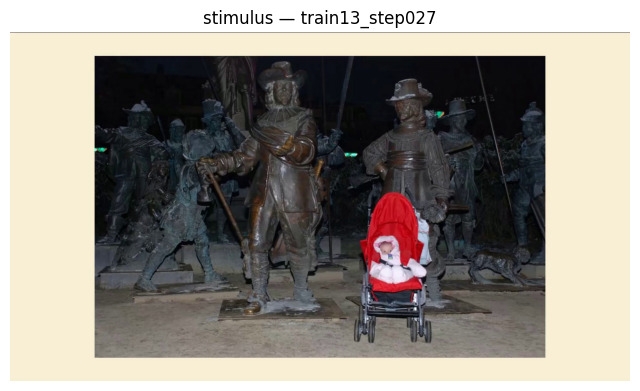

In [4]:
stimulus = bundle.get_stimulus(exp_key)

plt.figure(figsize=(8, 5))
plt.imshow(stimulus)
plt.title(f"stimulus — {exp_key}")
plt.axis("off")
plt.show()

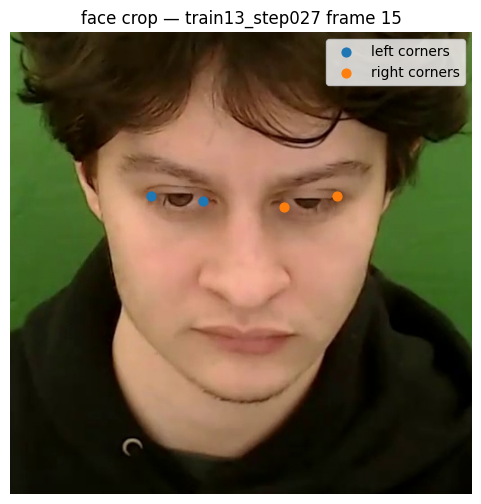

{'left': array([[156.15875, 181.08832],
        [213.28491, 187.08948]], dtype=float32),
 'right': array([[302.82544, 193.08832],
        [361.59167, 181.12549]], dtype=float32)}

In [5]:
face_crop = bundle.get_face_crop(exp_key, frame, FACE_CROPS_ROOT)
coords = bundle.get_eye_coords_in_crop(exp_key, frame)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(face_crop)
for eye, pts in coords.items():
    ax.scatter(pts[:, 0], pts[:, 1], label=f"{eye} corners", s=40)
ax.set_title(f"face crop — {exp_key} frame {frame}")
ax.legend()
ax.axis("off")
plt.show()

coords

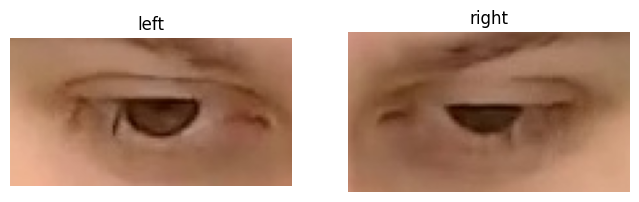

In [6]:
# Quick-and-dirty eye crop preview: bounding box around the two corners,
# padded. Not the real compute_eye_crop_window/crop_eye geometry (R0 TODO) —
# just enough to visually sanity-check the corner coordinates land on the eye.
def rough_eye_crop(face_crop, eye_corners, pad=25):
    xs = eye_corners[:, 0]
    ys = eye_corners[:, 1]
    x0, x1 = int(xs.min() - pad), int(xs.max() + pad)
    y0, y1 = int(ys.min() - pad), int(ys.max() + pad)
    x0, y0 = max(x0, 0), max(y0, 0)
    x1, y1 = min(x1, face_crop.shape[1]), min(y1, face_crop.shape[0])
    return face_crop[y0:y1, x0:x1]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, eye in zip(axes, ("left", "right")):
    ax.imshow(rough_eye_crop(face_crop, coords[eye]))
    ax.set_title(eye)
    ax.axis("off")
plt.show()

In [7]:
print("g_tobii (left, this frame):", gaze_left["g_tobii"][frame])
print("R (left, this frame):\n", gaze_left["R"][frame])
print("h (left, this frame):", gaze_left["h"][frame])
print("o (left, this frame):", gaze_left["o"][frame])

g_tobii (left, this frame): [-0.32346418 -0.00988747]
R (left, this frame):
 [[ 0.9884651   0.00271678 -0.15142472]
 [-0.00423783  0.99994373 -0.0097231 ]
 [ 0.1513898   0.01025265  0.98842096]]
h (left, this frame): [-0.447261   -0.09127104]
o (left, this frame): [ 92.28628    6.249954 602.53534 ]
